# `CRO` reproduces the simulated ENSO characteristics in climate models 

This tutorial demonstrates how to use `pyCRO` to calibrate the stochastic Recharge Oscillator (RO) model against output from a climate model ensemble. Using the CESM1 Large Ensemble (CESM1-LE) as an example, we show how the fitted RO can reproduce the simulated ENSO dynamics and statistics of a comprehensive Earth system model.

Unlike the previous tutorial, which focused on observations, this example illustrates how `pyCRO` can be applied to climate model simulations. The same workflow can be readily extended to other CMIP6 models, single-model initial-condition large ensembles (SMILEs), or coupled model experiments.

Starting from simulated Niño3.4 SST anomalies and Warm Water Volume (WWV), we will

- fit Recharge Oscillator parameters for every ensemble member,
- estimate the ensemble-mean RO parameters,
- perform long stochastic ensemble simulations using the fitted ensenble mean parameters,
- compare the simulated RO statistics with those of CESM1-LE, and
- evaluate how well the simplified stochastic model reproduces the model's ENSO behavior.

---

This notebook was contributed by [Sen Zhao](https://senzhao.netlify.app/).

Contacts: Sen Zhao <zhaos@hawaii.edu>, Soong-Ki Kim <soong-ki.kim@yale.edu>


In [1]:
%config IPCompleter.greedy = True
%matplotlib inline
%config InlineBackend.figure_format='retina'

%load_ext autoreload
%autoreload 2

import os
import sys
    
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

from joblib import Parallel, delayed

## comment this if you install pyCRO already
sys.path.append(os.path.abspath("../../../"))

import pyCRO

## Load XRO for using some stats and plot functions
import XRO

## Loading CESM1-LE ENSO data

We begin by loading monthly Niño3.4 SST anomalies and Warm Water Volume (WWV) from the CESM1 Large Ensemble (CESM1-LE).

Each ensemble member represents an independent realization of internal climate variability under identical external forcing. Together, these members provide an ideal dataset for estimating robust Recharge Oscillator parameters and quantifying uncertainty associated with internal variability.


In [2]:
model = 'CESM1'
model_ds = pyCRO.ROdata_load(name='CESM1_LENS').sel(time=slice("1990", "2014"))
model_ds

<xarray.Dataset> Size: 192kB
Dimensions:  (time: 300, member: 39)
Coordinates:
  * member   (member) <U3 468B '001' '002' '003' '004' ... '103' '104' '105'
  * time     (time) datetime64[ns] 2kB 1990-01-01 1990-02-01 ... 2014-12-01
    month    (time) int64 2kB ...
Data variables:
    Nino34   (time, member) float64 94kB ...
    WWV      (time, member) float64 94kB ...

## Fit the Recharge Oscillator to each ensemble member

The Recharge Oscillator parameters are estimated independently for every ensemble member.

Because the CESM1 Large Ensemble contains 39 realizations, we use parallel processing to accelerate the fitting procedure. Each member yields one set of physically interpretable parameters describing

In [3]:
par_option_T = {"R": 3, "F1": 3, "b_T": 1, "c_T": 1, "d_T": 1}
par_option_h = {"F2": 3, "epsilon": 3, "b_h": 1}
par_option_noise = {"T": "red", "h": "red", "T_type": "additive"}
verbose = False

# get ensemble mean of fit for all the members using multi-processing 


def fit_member(member):
    """Fit CRO parameters for a single ensemble member."""
    return pyCRO.RO_fitting(
        model_ds.Nino34.sel(member=member),
        model_ds.WWV.sel(member=member),
        par_option_T,
        par_option_h,
        par_option_noise,
        verbose=False,
    )

# Parallel fitting
member_ids = model_ds.member.values
fit_results = Parallel(n_jobs=-1)(
    delayed(fit_member)(member) for member in member_ids
)

## Plot CESM1-LE ensemble mean and spread of RO parameters

The RO parameters estimated from individual CESM1-LE ensemble members exhibit substantial spread due to internal climate variability. Although all members are generated by the same climate model under identical external forcing, each realization follows a different sequence of stochastic climate fluctuations, leading to differences in the fitted RO parameters.


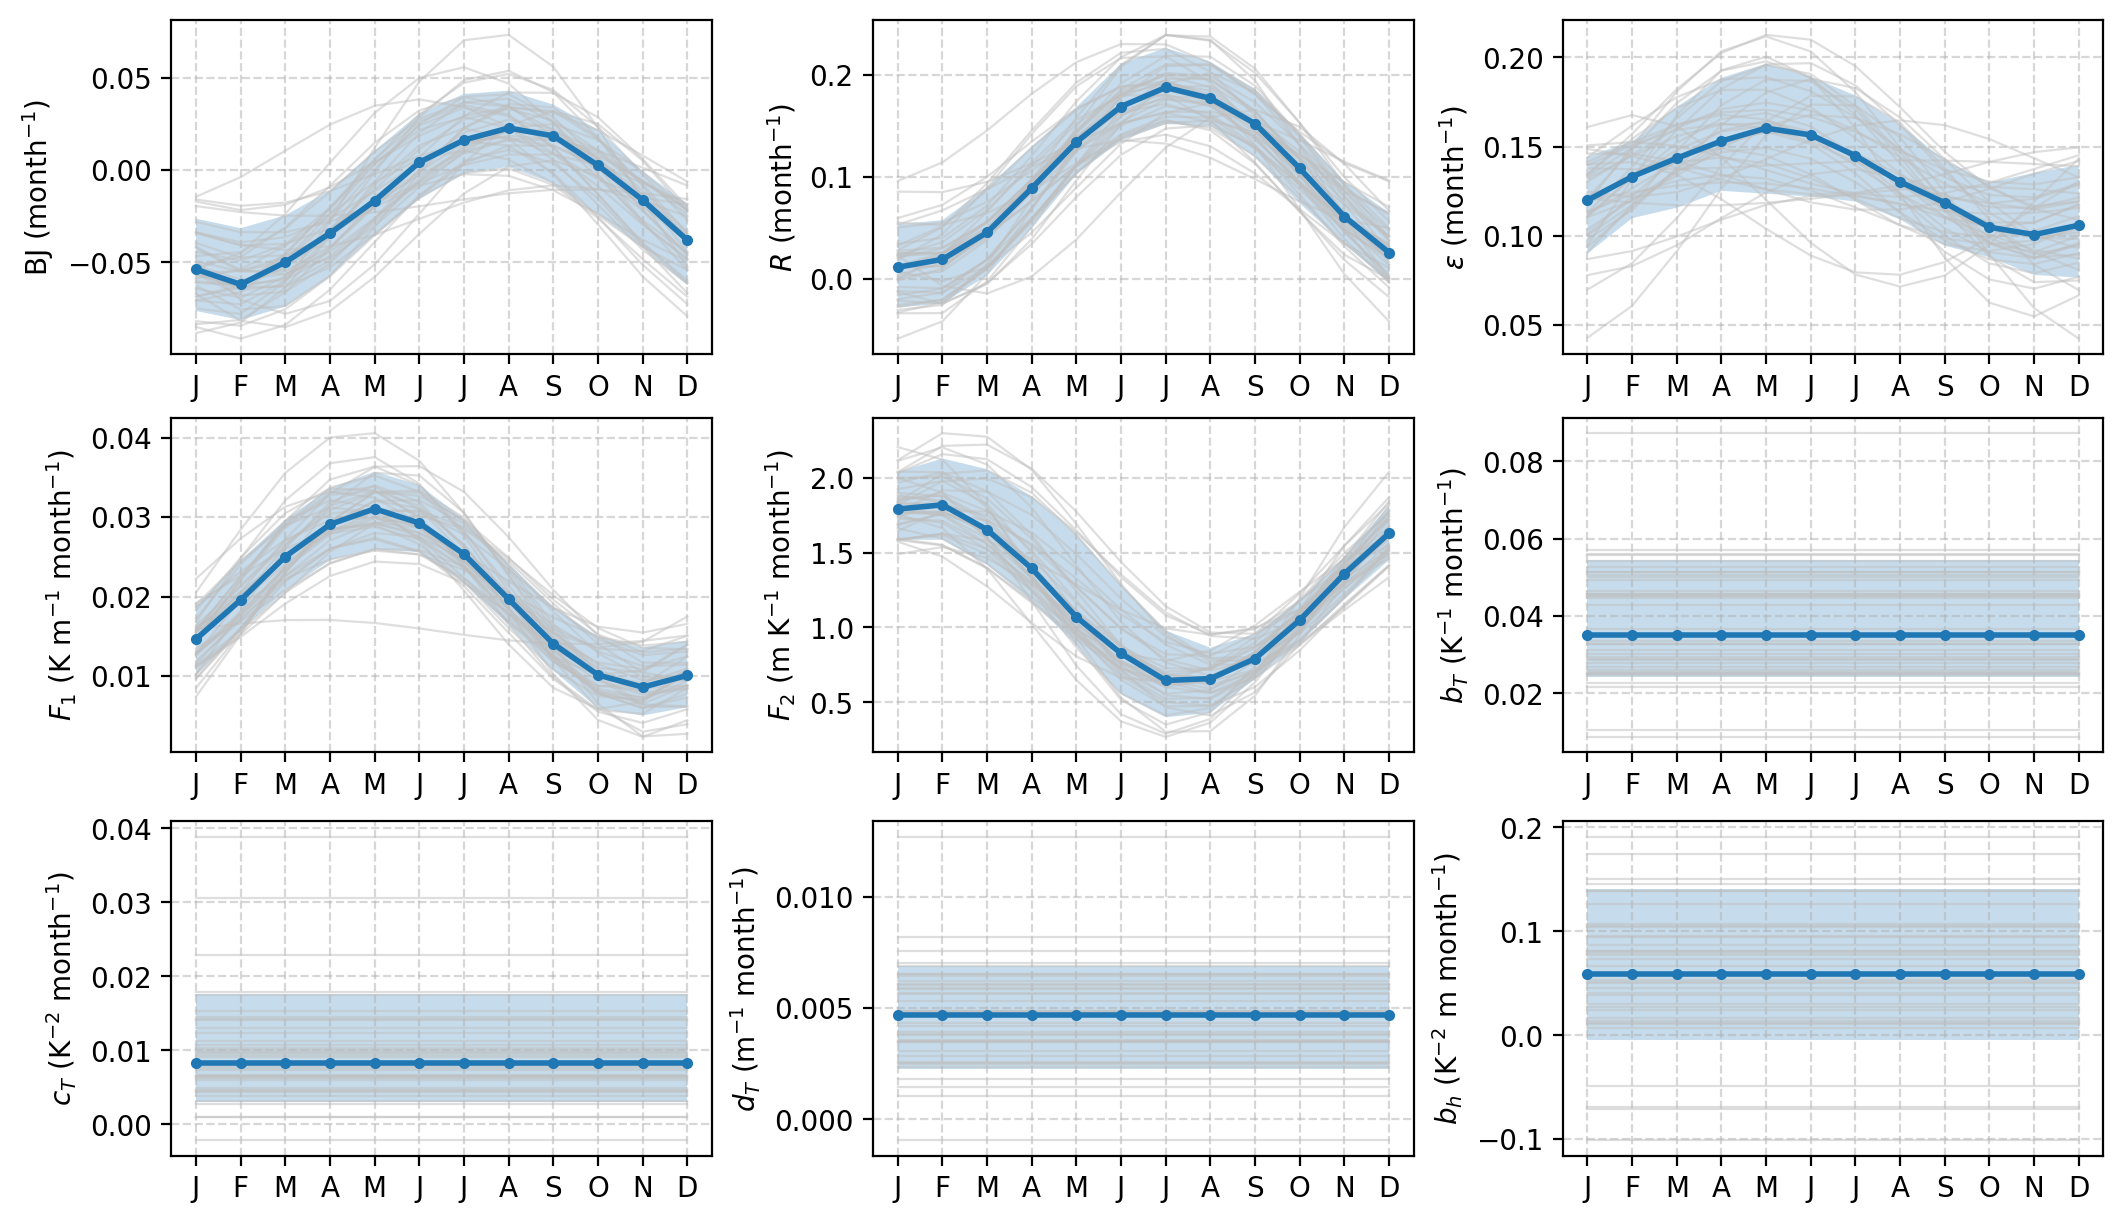

In [4]:
# spread option ['std', 'q10_q10']
axes = pyCRO.plot_ens_RO_par(fit_results, spread='q10_q90', center='median', ncol=3, show_members=True, member_alpha=0.5)

In [5]:
def get_ensemble_mean_fit(fit_results, method="mean"):
    """
    Aggregate CRO fitting results across ensemble members.

    Parameters
    ----------
    fit_results : list of dict
        List of parameter dictionaries returned by ``pyCRO.RO_fitting``,
        with one dictionary per ensemble member.

    method : {"mean", "median"}, default="mean"
        Aggregation method applied across the ensemble dimension.

    Returns
    -------
    dict
        Dictionary containing the aggregated parameter values. Each value is
        a NumPy array whose length matches the corresponding parameter in the
        fitting output.

    Notes
    -----
    Parameters with fewer coefficients are padded with NaNs before
    aggregation. Empty parameters (e.g., ``B``) are returned as empty arrays.
    """
    if not fit_results:
        raise ValueError("fit_results is empty.")

    par_model_fit = {}

    for key in fit_results[0]:
        # Maximum number of coefficients for this parameter
        max_len = max(len(result[key]) for result in fit_results)

        if max_len == 0:
            par_model_fit[key] = []
            continue

        values = np.full((len(fit_results), max_len), np.nan)

        for i, result in enumerate(fit_results):
            n = len(result[key])
            if n > 0:
                values[i, :n] = result[key]

        if method == "mean":
            par_model_fit[key] = np.nanmean(values, axis=0).tolist()
        elif method == "median":
            par_model_fit[key] = np.nanmedian(values, axis=0).tolist()
        elif method == "std":
            par_model_fit[key] = np.nanstd(values, axis=0).tolist()
        else:
            raise ValueError(f"Unknown method: {method}")

    return par_model_fit

model_fit_em = get_ensemble_mean_fit(fit_results, method='mean')
model_fit_em

{'R': [0.09848583730110598, 0.09032112989803304, -1.947750562650644],
 'F1': [0.019900669116159248, 0.011279737727262894, -0.7814715863373812],
 'F2': [1.2465541990179974, 0.6199578644514556, 0.9538212902129936],
 'epsilon': [0.1312493671393928, 0.034409836706950955, -0.571647121060078],
 'b_T': [0.03834793279882867],
 'c_T': [0.009989906027608507],
 'd_T': [0.0046397403898260185],
 'b_h': [0.060643837095749845],
 'sigma_T': [0.17434566298774531],
 'sigma_h': [1.0896711691996557],
 'B': [],
 'm_T': [1.6874018858511477],
 'm_h': [1.375501781344002],
 'n_T': [0.0],
 'n_h': [0.0],
 'n_g': [2.0]}

## Compute ensemble-mean RO parameters

Individual ensemble members exhibit natural variability in their fitted parameters.

To obtain a representative Recharge Oscillator for CESM1, we aggregate the fitted parameters across all ensemble members and compute the ensemble-mean parameter set. This averaged parameterization captures the characteristic ENSO dynamics simulated by the climate model while reducing the influence of internal variability.

The resulting parameters can also be visualized to compare the relative strengths of different physical processes represented by the Recharge Oscillator.

## Generate stochastic ensemble simulations

Using the ensemble-mean RO parameters, we integrate the stochastic Recharge Oscillator forward in time.

A 100-member, 200-year stochastic ensemble is generated to produce stable climate statistics that can be directly compared with those from CESM1-LE.

In [6]:
RO_sim = pyCRO.CRO_simulate(model_fit_em, IC=[0, 0], N=12*200, NE=100, verbose=False)
# rename back to same name with input CESM1_LENS
RO_sim = RO_sim.rename({'T': 'Nino34', 'h': 'WWV', })
RO_sim

<xarray.Dataset> Size: 4MB
Dimensions:  (time: 2400, member: 100)
Coordinates:
  * time     (time) datetime64[ns] 19kB 1900-01-01 1900-02-01 ... 2099-12-01
  * member   (member) int64 800B 0 1 2 3 4 5 6 7 8 ... 92 93 94 95 96 97 98 99
Data variables:
    Nino34   (time, member) float64 2MB 0.0 0.0 0.0 0.0 ... -1.594 -1.763 1.534
    WWV      (time, member) float64 2MB 0.0 0.0 0.0 0.0 ... -3.171 1.947 -5.0

## Seasonal modulation of ENSO amplitude

One of the defining characteristics of ENSO is its seasonal synchronization, with variability peaking during boreal winter.

Here we compare the seasonal evolution of Niño3.4 standard deviation between CESM1-LE and the stochastic RO simulations to assess whether the fitted model reproduces the model's seasonal phase locking.

Text(0.5, 1.0, 'CRO simulates ENSO seasonal synchronization')

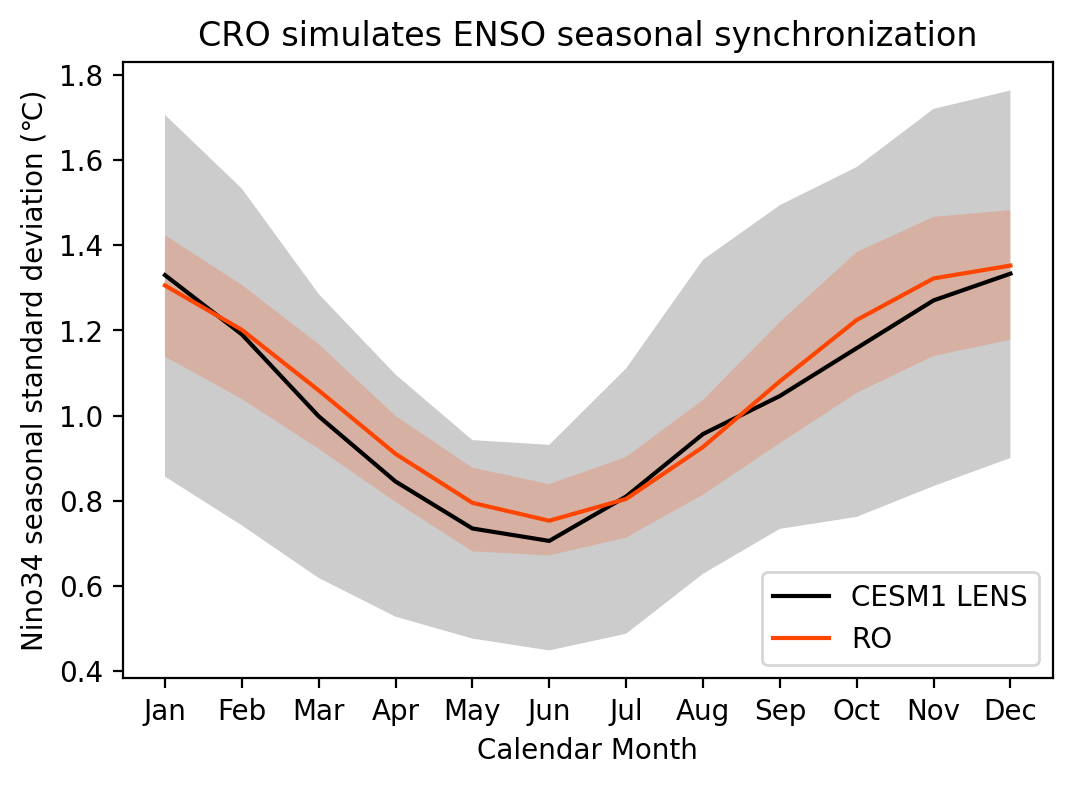

In [7]:
model_seaSD = model_ds.groupby('time.month').std('time')
RO_seaSD = RO_sim.groupby('time.month').std('time')

sel_var = "Nino34"
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
XRO.plot_fill_between(model_seaSD[sel_var], xtime=model_seaSD.month, ax=ax, label='CESM1 LENS', c='black', option=0)
XRO.plot_fill_between(RO_seaSD[sel_var], xtime=RO_seaSD.month, ax=ax, label='RO', option=0)

plt.legend()
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.ylabel('Nino34 seasonal standard deviation (℃)')
plt.xlabel('Calendar Month')
plt.title('CRO simulates ENSO seasonal synchronization')

## Seasonal varying skewness

ENSO exhibits nonlinear behavior, with warm events often stronger than cold events.

The seasonal evolution of Niño3.4 skewness provides an important test of whether the fitted Recharge Oscillator captures the nonlinear asymmetry simulated by CESM1.


Text(0.5, 1.0, 'CRO simulates ENSO SST skewness')

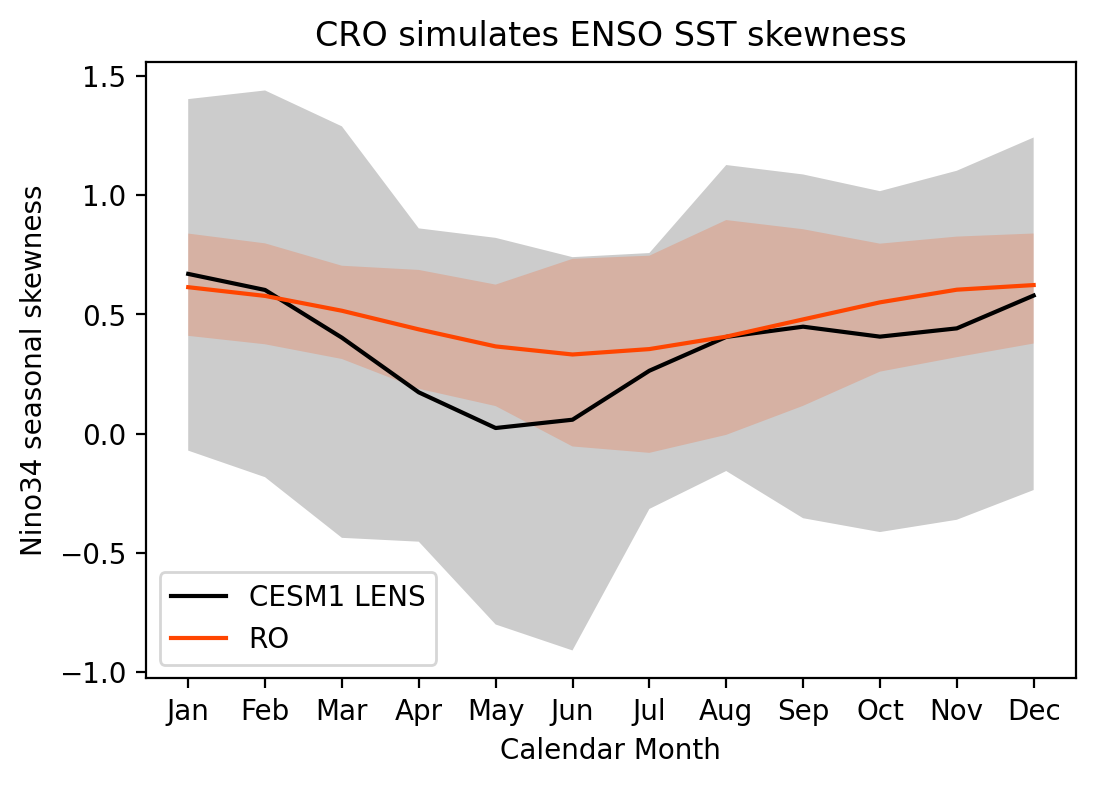

In [8]:
model_seaSK = model_ds.groupby('time.month').skew('time')
RO_seaSK = RO_sim.groupby('time.month').skew('time')

sel_var = "Nino34"
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
XRO.plot_fill_between(model_seaSK[sel_var], xtime=model_seaSK.month, ax=ax, label='CESM1 LENS', c='black', option=0)
XRO.plot_fill_between(RO_seaSK[sel_var], xtime=RO_seaSK.month, ax=ax, label='RO', option=0)

plt.legend()
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.ylabel('Nino34 seasonal skewness')
plt.xlabel('Calendar Month')
plt.title('CRO simulates ENSO SST skewness')

## Autocorrelation / Cross correlation
Next, we evaluate the temporal evolution of ENSO using autocorrelation and cross-correlation analyses.

These diagnostics assess whether the Recharge Oscillator reproduces

- the persistence of Niño3.4 SST anomalies,
- the recharge of equatorial Pacific heat content prior to El Niño development, and
- the discharge process following ENSO peak events.

Agreement between the stochastic simulations and CESM1 indicates that the fitted RO captures the essential coupled ocean-atmosphere dynamics governing ENSO evolution.


In [9]:
model_ccr = XRO.xcorr(model_ds, model_ds['Nino34'], maxlags=36)
RO_ccr = XRO.xcorr(RO_sim, RO_sim['Nino34'], maxlags=36)

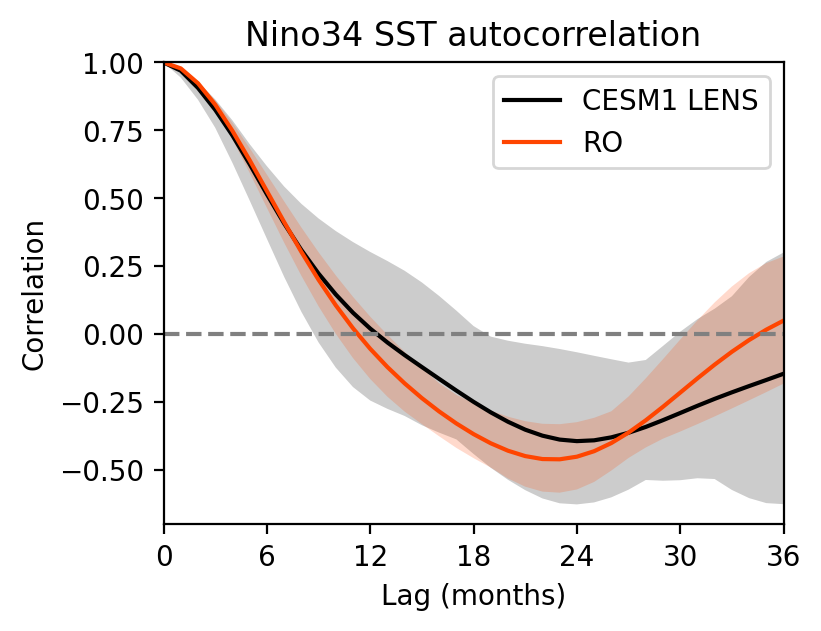

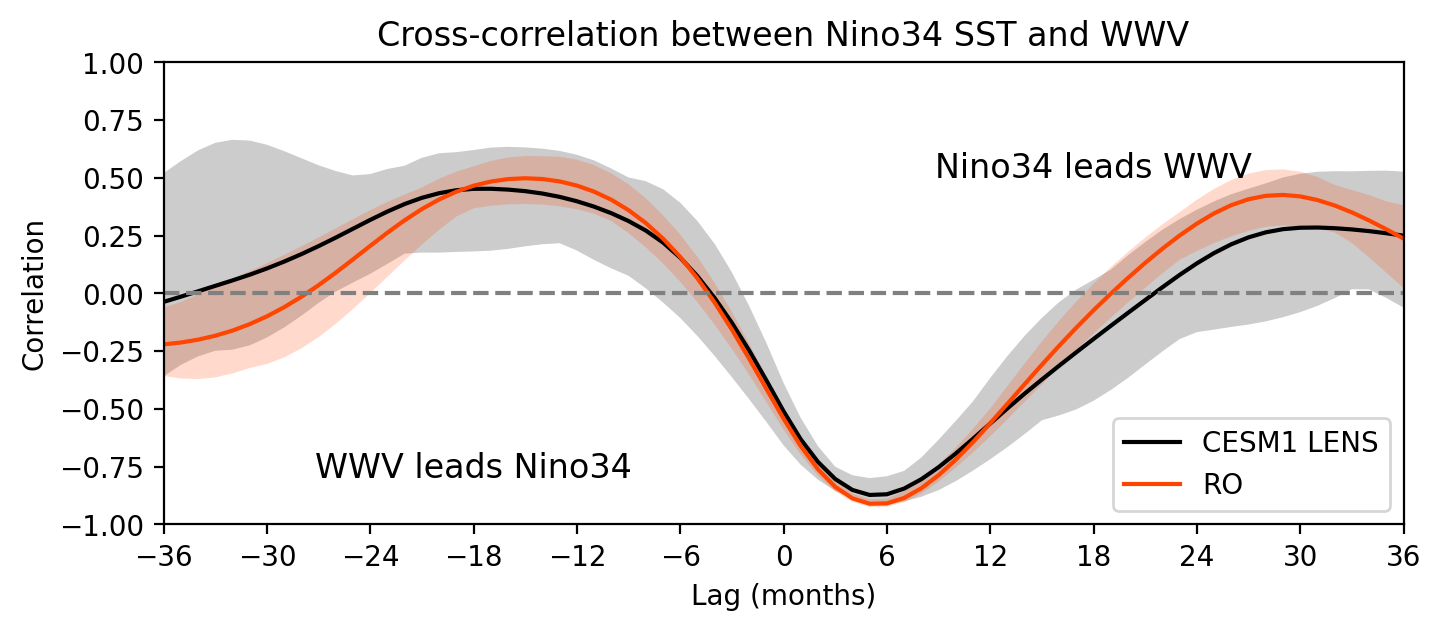

In [10]:
sel_var = "Nino34"

fig, ax = plt.subplots(1, 1, figsize=(4, 3))
XRO.plot_fill_between(model_ccr[sel_var], xtime=model_ccr.lag, ax=ax, label='CESM1 LENS', c='black', option=0)
XRO.plot_fill_between(RO_ccr[sel_var], xtime=RO_ccr.lag, ax=ax, label='RO', option=0)
ax.axhline(0, ls='--', c='gray')
ax.set_ylim([-0.7, 1])
ax.set_ylabel("Correlation")
ax.set_title("Nino34 SST autocorrelation")
ax.set_xlabel("Lag (months)")
ax.set_xticks(np.arange(-36, 37, step=6))
ax.set_xlim([0, 36])
ax.legend()


sel_var = "WWV"

fig, ax = plt.subplots(1, 1, figsize=(8, 3))
XRO.plot_fill_between(model_ccr[sel_var], xtime=model_ccr.lag, ax=ax, label='CESM1 LENS', c='black', option=0)
XRO.plot_fill_between(RO_ccr[sel_var], xtime=RO_ccr.lag, ax=ax, label='RO', option=0)
ax.set_xlim([-36, 36])
ax.axhline(0, ls='--', c='gray')
ax.text(0.25, 0.1,'WWV leads Nino34', ha='center', transform=ax.transAxes, fontsize='large')
ax.text(0.75, 0.75,'Nino34 leads WWV', ha='center', transform=ax.transAxes, fontsize='large')
ax.set_ylim([-1, 1])
ax.set_ylabel("Correlation")
ax.set_xlabel("Lag (months)")
ax.set_xticks(np.arange(-36, 37, step=6))

ax.set_title("Cross-correlation between Nino34 SST and WWV")
ax.legend()


## ENSO spectrum analysis

Finally, we examine the frequency characteristics of the simulated ENSO variability using Thomson's multitaper spectral estimator (See `pmtm` in XRO `stats.py`).

The observed ENSO spectrum is characterized by

- a dominant peak near **2.5–5.5 years (`fE`)**, corresponding to the intrinsic ENSO oscillation, and
- weaker combination modes (`1-fE` and `1+fE`) produced by interactions between the annual cycle and ENSO.

Matching the simulated spectrum provides a stringent test that the simplified stochastic model captures the principal timescales of ENSO variability simulated by CESM1.

Reference: Stuecker, M. F., Timmermann, A., Jin, F.-F., McGregor, S., & Ren, H.-L. (2013). A combination mode of the annual cycle and the El Niño/Southern Oscillation. Nature Geoscience, 6(7), 540–544. https://doi.org/10.1038/ngeo1826


In [11]:
psd_model, psd_sig_model, psd_ci_model = XRO.pmtm( model_ds['Nino34'], dim='time', dt=1/12, nw=3, lag1_r=None)
psd_RO, psd_sig_RO, psd_ci_RO = XRO.pmtm( RO_sim['Nino34'], dim='time', dt=1/12, nw=3, lag1_r=None)

Text(0.5, 1.0, 'Spectrum of Niño3.4 SST anomaly')

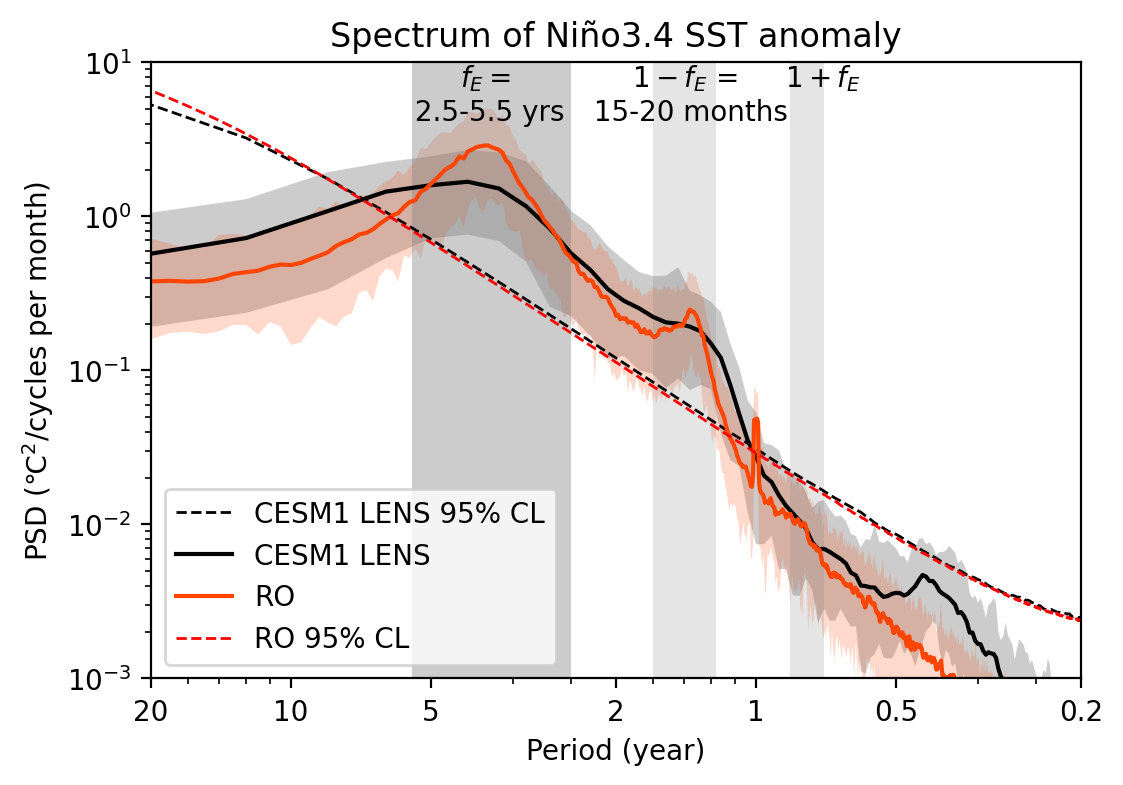

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

# ax.loglog(psd_obs.freq, psd_obs, lw=1.5, color='k', label='ORAS5')
# ax.plot(psd_sig_obs.freq, psd_sig_obs, lw=1., color='k', linestyle='--', label='ORAS5 95% CL')
ax.loglog(psd_sig_model.freq, psd_sig_model.median('member'), lw=1., color='k', linestyle='--', label='CESM1 LENS 95% CL')
XRO.plot_fill_between(psd_model, xtime=psd_model.freq, ax=ax, label='CESM1 LENS', c='k', option=0.05)

XRO.plot_fill_between(psd_RO, xtime=psd_RO.freq, ax=ax, label='RO', option=0.05)
ax.plot(psd_sig_RO.freq, psd_sig_RO.median('member'), lw=1., color='red', linestyle='--', label='RO 95% CL')

per = [50,20,10,5,2,1,0.5,0.2]
xt = 1.0/np.array(per)
ax.set_xticks(xt)
ax.set_xticklabels(map(str, per))
ax.set_ylabel('PSD (℃$^2$/cycles per month)')
ax.set_xlabel('Period (year)')
ax.set_xlim([1/20, 5])
ax.set_ylim([1e-3, 10])

ax.legend(loc='lower left')

y_min, y_max = ax.get_ylim()
Mfreq_enso = np.array([1/2.5, 1/5.5])
Mfreq_fplus = 1 + Mfreq_enso
Mfreq_fmins = 1 - Mfreq_enso

ax.fill_between(Mfreq_enso, y_min, y_max, fc='gray', alpha=0.4)
ax.fill_between(Mfreq_fplus, y_min, y_max, fc='gray',  alpha=0.2)
ax.fill_between(Mfreq_fmins, y_min, y_max, fc='gray', alpha=0.2)

ax.text(np.mean(Mfreq_enso)*0.9, y_max, '$f_{E}=$\n 2.5-5.5 yrs', ha='center', va='top')
ax.text(np.mean(Mfreq_fplus)+0.1, y_max, '$1+f_{E}$', ha='center', va='top')

ax.text(np.mean(Mfreq_fmins), y_max, '$1-f_{E}$ = \n 15-20 months', ha='center', va='top')
ax.set_title('Spectrum of Niño3.4 SST anomaly')

## Summary

In this tutorial, we

- fitted the Recharge Oscillator to every CESM1 Large Ensemble member,
- estimated representative ensemble-mean RO parameters,
- generated long stochastic ensemble simulations,
- reproduced the simulated seasonal synchronization of ENSO,
- captured the nonlinear asymmetry between El Niño and La Niña,
- recovered the recharge–discharge relationship between Niño3.4 SST and WWV, and
- reproduced the dominant spectral characteristics of ENSO simulated by CESM1.

This workflow demonstrates that `pyCRO` provides an efficient statistical emulator of ENSO dynamics in comprehensive climate models while retaining a clear physical interpretation of the governing processes.


Beyond reproducing climate model behavior, `pyCRO` enables process-oriented analyses of ENSO dynamics. For example, by fitting the Recharge Oscillator to **30-year sliding windows** of CESM1-LE simulations, the temporal evolution of the fitted parameters can be tracked. This makes it possible to identify which physical processes—such as changes in ocean–atmosphere coupling, damping, nonlinear feedbacks, or stochastic forcing—are primarily responsible for changes in ENSO characteristics over time. Such analyses provide a computationally efficient framework for attributing changes in ENSO dynamics in climate model simulations and can be readily extended to CMIP6 models and future climate projections.